In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
df = pd.read_csv("data/Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [8]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

In [11]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({1:'Yes',0:'No'})

In [12]:
df.to_csv("data/cleaned_telco_customer_churn.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [13]:
print("Total Customers:", len(df))
print("Churn Rate:", df['Churn'].mean()*100)
print(df.describe())

Total Customers: 7043
Churn Rate: 26.536987079369588
            tenure  MonthlyCharges  TotalCharges        Churn
count  7043.000000     7043.000000   7043.000000  7043.000000
mean     32.371149       64.761692   2281.916928     0.265370
std      24.559481       30.090047   2265.270398     0.441561
min       0.000000       18.250000     18.800000     0.000000
25%       9.000000       35.500000    402.225000     0.000000
50%      29.000000       70.350000   1397.475000     0.000000
75%      55.000000       89.850000   3786.600000     1.000000
max      72.000000      118.750000   8684.800000     1.000000


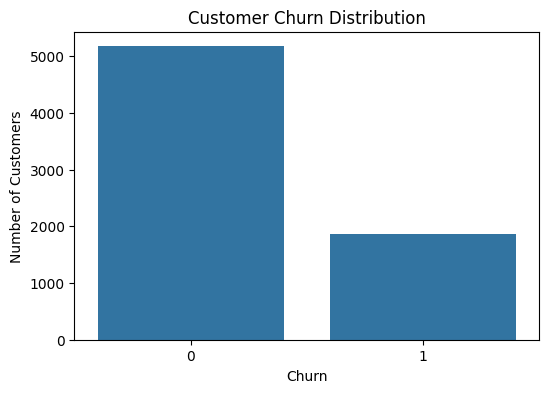

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.savefig("screenshots/churn_distribution.png")
plt.show()

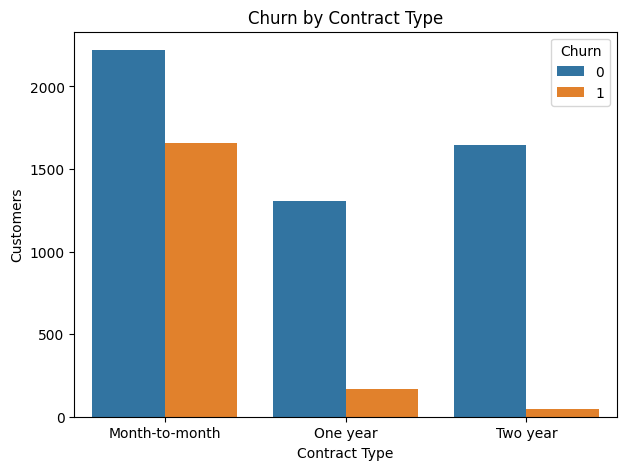

In [15]:
plt.figure(figsize=(7,5))

sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customers")

plt.savefig("screenshots/churn_by_contract.png")
plt.show()

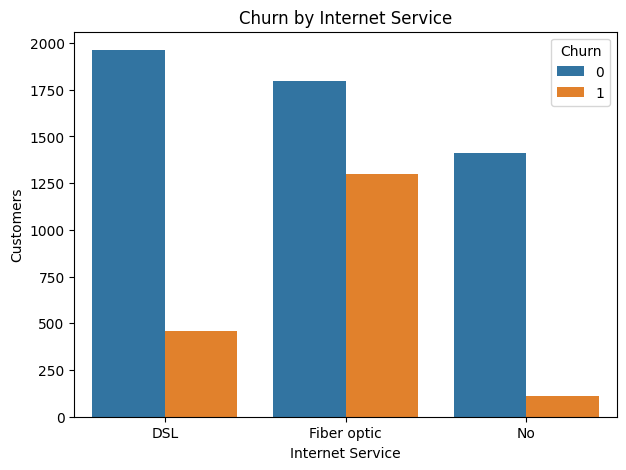

In [16]:
plt.figure(figsize=(7,5))

sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Customers")

plt.savefig("screenshots/churn_by_internet_service.png")
plt.show()

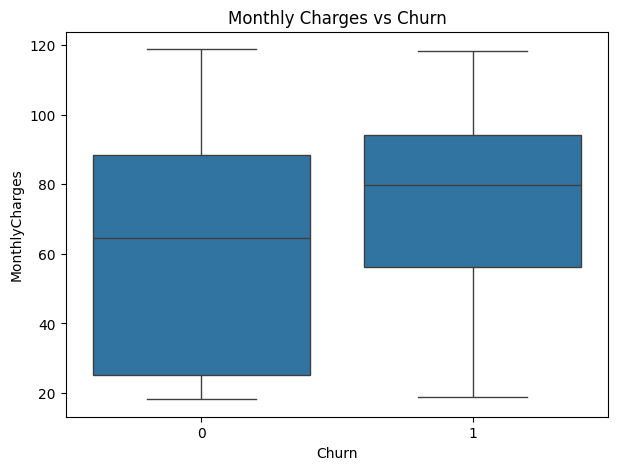

In [17]:
plt.figure(figsize=(7,5))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")

plt.savefig("screenshots/monthly_charges_vs_churn.png")
plt.show()

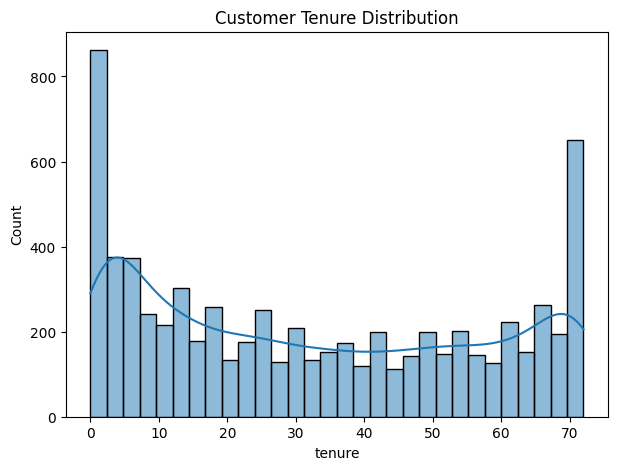

In [18]:
plt.figure(figsize=(7,5))

sns.histplot(df['tenure'], bins=30, kde=True)

plt.title("Customer Tenure Distribution")

plt.savefig("screenshots/tenure_distribution.png")
plt.show()

In [19]:
df['CustomerLifetimeValue'] = df['MonthlyCharges'] * df['tenure']

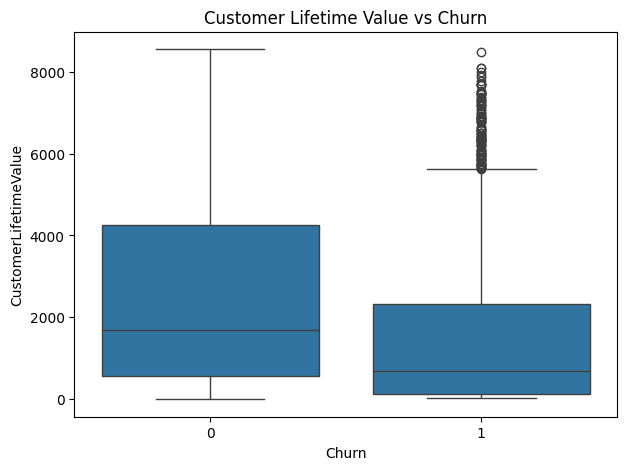

In [20]:
plt.figure(figsize=(7,5))

sns.boxplot(x='Churn', y='CustomerLifetimeValue', data=df)

plt.title("Customer Lifetime Value vs Churn")

plt.savefig("screenshots/clv_vs_churn.png")
plt.show()

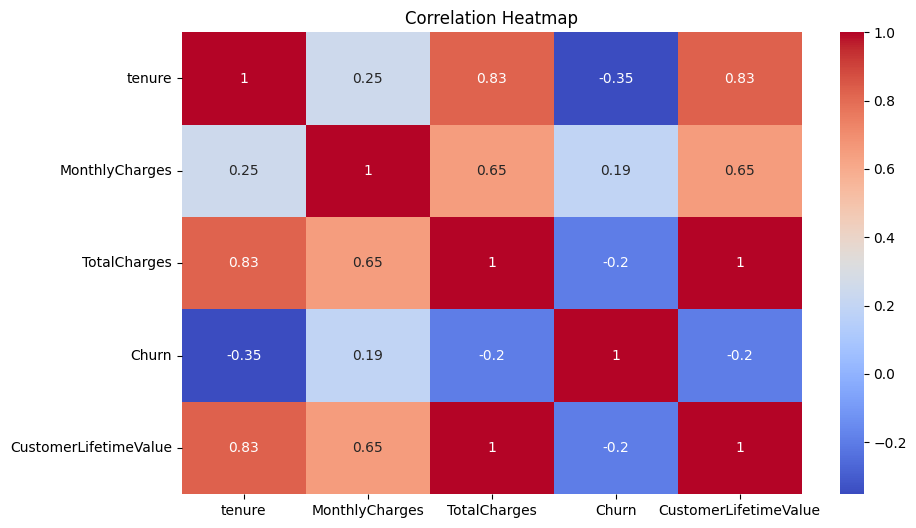

In [21]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.savefig("screenshots/correlation_heatmap.png")
plt.show()